In [1]:
import pandas as pd

In [2]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
from utils import *

In [3]:
df_tcga = pd.read_csv('../TCGA_tumor_boundary_core_DEG(Virtual_gene_analysis)/df_all_TCGA.csv')
df_tcga.shape

(513477, 7)

In [4]:
df_cptac = pd.read_csv('../Validation_on_CPTAC/Virtual_gene/CPTAC_df_patient.csv')
df_cptac.shape

(175994, 3)

In [5]:
df_tcga

,gene,inner_5,outer_5,tumor_all,tumor_core,sample,logFC_inner_vs_core
0,A2M,1.248761,1.252843,1.245625,0.722540,S11,-0.789347
1,AAMP,0.087034,0.031848,0.087175,0.110693,S11,0.346904
2,ACADVL,0.154110,0.065363,0.154302,0.186379,S11,0.274275
3,ACBD3,0.116542,0.036017,0.116823,0.163736,S11,0.490519
4,ACOX1,0.091627,0.032490,0.091571,0.082239,S11,-0.155946
...,...,...,...,...,...,...,...
513472,protein_VIM,1281.161198,1959.167638,1384.551606,1430.952913,S541,0.159524
513473,protein_mouse_IgG1k,50.216113,53.114783,50.458561,50.567371,S541,0.010056
513474,protein_mouse_IgG2a,57.911194,58.689318,57.934129,57.944422,S541,0.000828
513475,protein_mouse_IgG2bk,23.965125,30.234730,23.599056,23.434765,S541,-0.032286


In [6]:
df_cptac

,patient_id,gene,logFC_inner_vs_core
0,C3L-00001,A2M,0.011234
1,C3L-00001,AAMP,-0.025619
2,C3L-00001,ACADVL,-0.004325
3,C3L-00001,ACBD3,-0.016022
4,C3L-00001,ACOX1,-0.013714
...,...,...,...
175989,C3N-04382,protein_VIM,0.012769
175990,C3N-04382,protein_mouse_IgG1k,-0.002169
175991,C3N-04382,protein_mouse_IgG2a,0.002109
175992,C3N-04382,protein_mouse_IgG2bk,-0.023437


In [7]:
# overlap_genes = ['SOCS3',
#  'FUCA1',
#  'CTSD',
#  'PLD3',
#  'protein_ACTA2',
#  'PPT1',
#  'DEPP1',
#  'SCGB3A1',
#  'CRIP1',
#  'CLPTM1L',
#  'GPX4',
#  'CTSS',
#  'ALDH2']

overlap_genes = ['SOCS3',
 'FUCA1',
 'JUNB',
 'CTSD',
 'PLD3',
 'PPT1',
 'DEPP1',
 'BHLHE40',
 'CRIP1',
 'GRN',
 'CLPTM1L',
 'ZFP36L2',
 'GPX4',
 'CTSS',
 'ALDH2',
 'ETS1']

/tmp/ipykernel_1311867/1868672344.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df.groupby("gene")["logFC_inner_vs_core"]
/tmp/ipykernel_1311867/1868672344.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


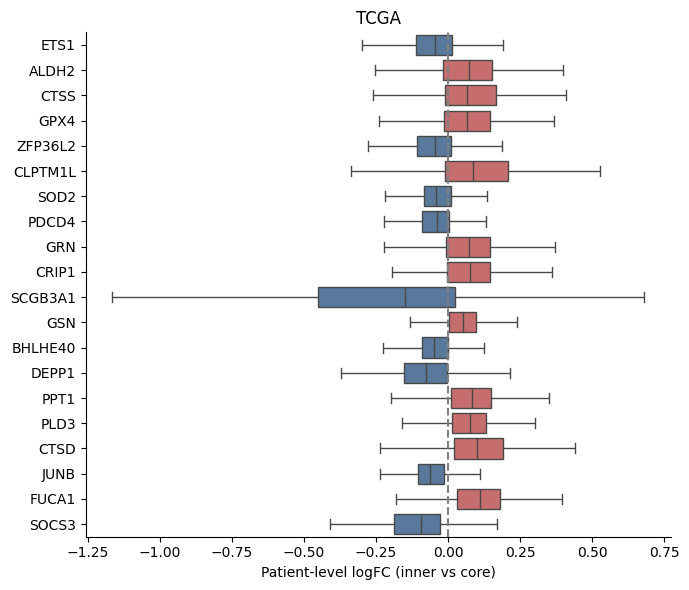

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = df_tcga[
    df_tcga["gene"].isin(overlap_genes)
].copy()

# 顺序
plot_df["gene"] = pd.Categorical(
    plot_df["gene"],
    categories=overlap_genes[::-1],
    ordered=True
)

# ----------------------------
# 根据每个gene的median决定颜色
# ----------------------------
medians = (
    plot_df.groupby("gene")["logFC_inner_vs_core"]
    .median()
)

palette = {
    g: "#D55E5E" if medians[g] > 0 else "#4C78A8"
    for g in medians.index
}
# 红 = boundary enriched
# 蓝 = core enriched

plt.figure(figsize=(7,6))

sns.boxplot(
    data=plot_df,
    x="logFC_inner_vs_core",
    y="gene",
    palette=palette,
    showfliers=False,
    linewidth=1
)

plt.axvline(0, linestyle="--", color="gray")

plt.xlabel("Patient-level logFC (inner vs core)")
plt.ylabel("")
plt.title("TCGA")

sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_1311867/3351587335.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df.groupby("gene")["logFC_inner_vs_core"]
/tmp/ipykernel_1311867/3351587335.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


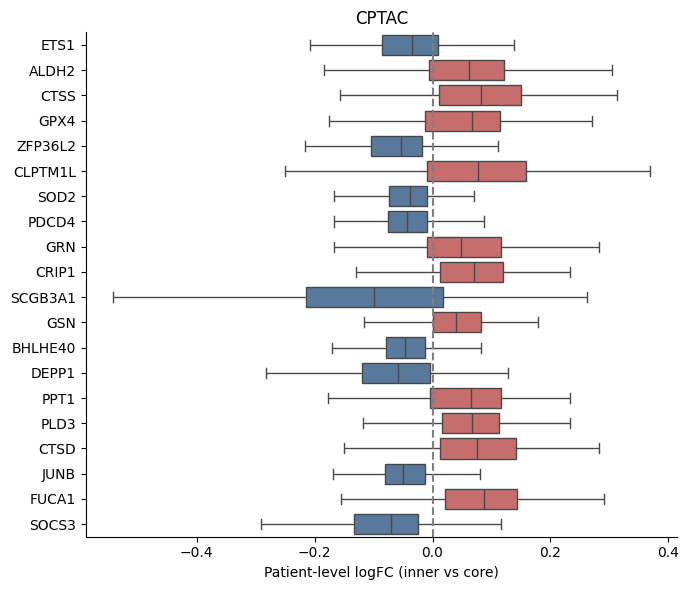

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = df_cptac[
    df_cptac["gene"].isin(overlap_genes)
].copy()

# 顺序
plot_df["gene"] = pd.Categorical(
    plot_df["gene"],
    categories=overlap_genes[::-1],
    ordered=True
)

# ----------------------------
# 根据每个gene的median决定颜色
# ----------------------------
medians = (
    plot_df.groupby("gene")["logFC_inner_vs_core"]
    .median()
)

palette = {
    g: "#D55E5E" if medians[g] > 0 else "#4C78A8"
    for g in medians.index
}
# 红 = boundary enriched
# 蓝 = core enriched

plt.figure(figsize=(7,6))

sns.boxplot(
    data=plot_df,
    x="logFC_inner_vs_core",
    y="gene",
    palette=palette,
    showfliers=False,
    linewidth=1
)

plt.axvline(0, linestyle="--", color="gray")

plt.xlabel("Patient-level logFC (inner vs core)")
plt.ylabel("")
plt.title("CPTAC")

sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_1311867/260575540.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


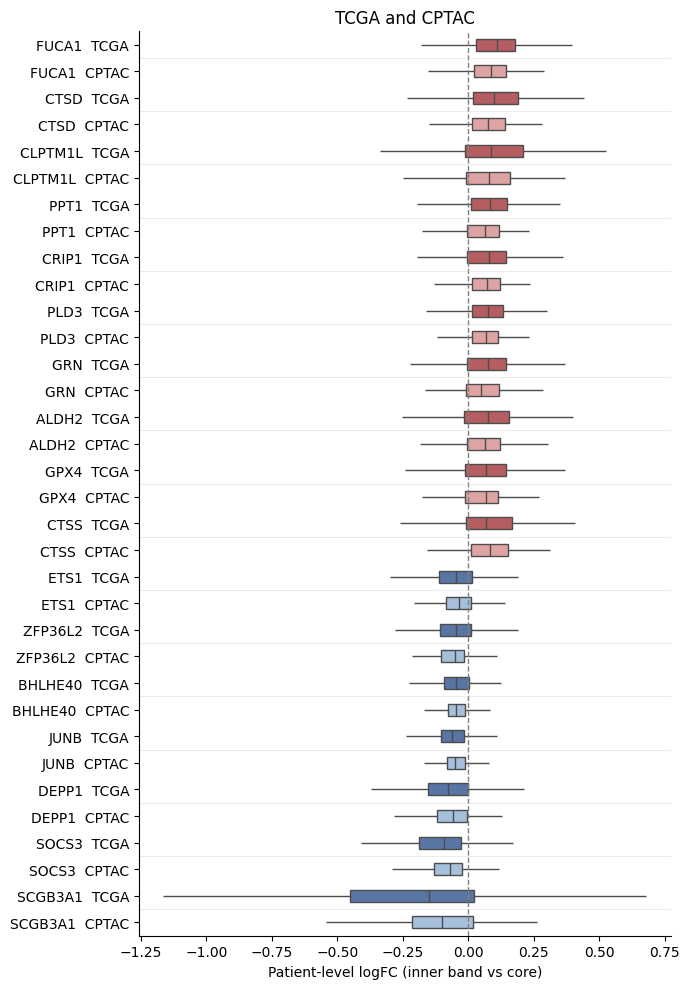

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# combine TCGA + CPTAC
# ----------------------------
df_tcga_plot = df_tcga[df_tcga["gene"].isin(overlap_genes)].copy()
df_tcga_plot["dataset"] = "TCGA"

df_cptac_plot = df_cptac[df_cptac["gene"].isin(overlap_genes)].copy()
df_cptac_plot["dataset"] = "CPTAC"

plot_df = pd.concat([df_tcga_plot, df_cptac_plot], axis=0).copy()

# ----------------------------
# 排序：按 TCGA median
# ----------------------------
tcga_medians = (
    df_tcga_plot
    .groupby("gene")["logFC_inner_vs_core"]
    .median()
    .sort_values(ascending=True)   # 从 core → inner
)

sorted_genes = tcga_medians.index.tolist()

# ----------------------------
# row label
# ----------------------------
plot_df["gene_dataset"] = plot_df["gene"] + "  " + plot_df["dataset"]

y_order = []
for g in sorted_genes[::-1]:   # 让 inner enriched 在上面
    y_order.extend([f"{g}  TCGA", f"{g}  CPTAC"])

plot_df["gene_dataset"] = pd.Categorical(
    plot_df["gene_dataset"],
    categories=y_order,
    ordered=True
)

# ----------------------------
# color palette
# ----------------------------
medians = (
    plot_df
    .groupby(["gene", "dataset"])["logFC_inner_vs_core"]
    .median()
)

color_map = {
    ("inner", "TCGA"): "#C44E52",
    ("inner", "CPTAC"): "#E89A9A",
    ("core", "TCGA"): "#4C72B0",
    ("core", "CPTAC"): "#9DBFE3",
}

palette = {}

for g in sorted_genes:
    for d in ["TCGA", "CPTAC"]:
        key = (g, d)
        if key not in medians.index:
            continue

        direction = "inner" if medians.loc[key] > 0 else "core"
        palette[f"{g}  {d}"] = color_map[(direction, d)]

# ----------------------------
# plot
# ----------------------------
plt.figure(figsize=(7, 10))

sns.boxplot(
    data=plot_df,
    x="logFC_inner_vs_core",
    y="gene_dataset",
    order=y_order,
    palette=palette,
    showfliers=False,
    showcaps=False,
    linewidth=1,
    width=0.45   # 🔥 变窄（原来是0.65）
)

plt.axvline(0, linestyle="--", color="gray", linewidth=1)

plt.xlabel("Patient-level logFC (inner band vs core)")
plt.ylabel("")
plt.title("TCGA and CPTAC")

sns.despine()

# 🔥 可选：每个gene加分隔线（强烈推荐）
for i in range(0, len(y_order), 2):
    plt.axhline(i + 0.5, color="lightgray", lw=0.6, alpha=0.5)

plt.tight_layout()
plt.show()

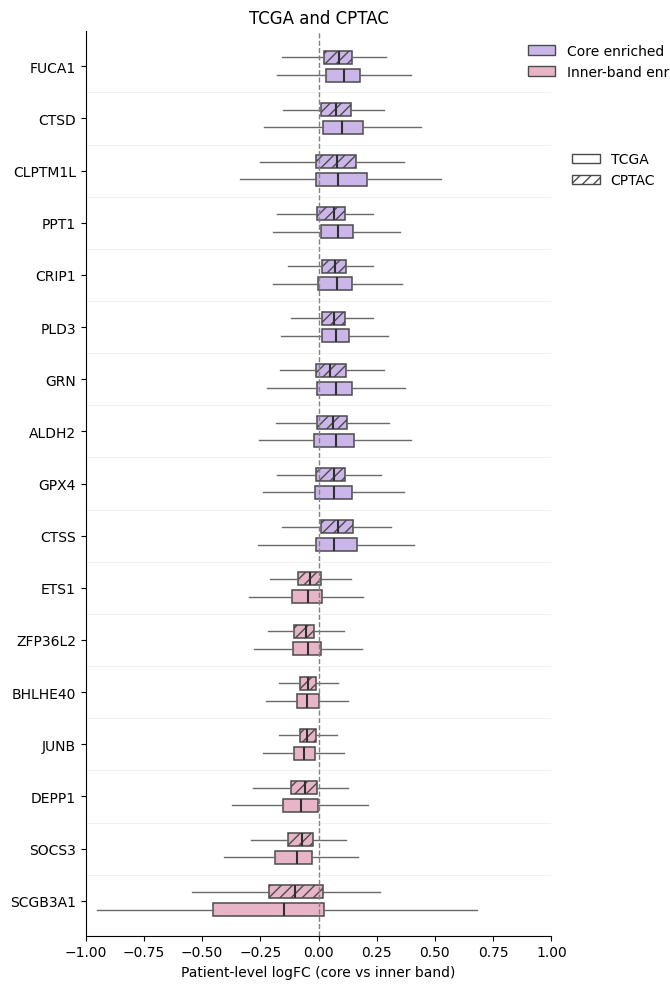

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ----------------------------
# combine TCGA + CPTAC
# ----------------------------
df_tcga_plot = df_tcga[df_tcga["gene"].isin(overlap_genes)].copy()
df_tcga_plot["dataset"] = "TCGA"

df_cptac_plot = df_cptac[df_cptac["gene"].isin(overlap_genes)].copy()
df_cptac_plot["dataset"] = "CPTAC"

plot_df = pd.concat([df_tcga_plot, df_cptac_plot], axis=0).copy()

# ----------------------------
# global clipping: abs(logFC) > 0.95
# ----------------------------
plot_df["logFC_inner_vs_core"] = plot_df["logFC_inner_vs_core"].clip(
    lower=-0.95,
    upper=0.95
)

# ----------------------------
# sort by TCGA median
# ----------------------------
tcga_medians = (
    plot_df[plot_df["dataset"] == "TCGA"]
    .groupby("gene")["logFC_inner_vs_core"]
    .median()
    .sort_values(ascending=True)
)

sorted_genes = tcga_medians.index.tolist()

# ----------------------------
# colors
# logFC > 0 = core enriched
# logFC < 0 = inner-band enriched
# ----------------------------
# direction_colors = {
#     "core": "#B7B5E4",    # lavender purple
#     "inner": "#A8D8D8",   # soft teal
# }

direction_colors = {
    "core": "#CBB6E9",    # 稍偏棕红（更高级）
    "inner": "#E8B5C8",   # dusty rose（你给的配色里很好看）
}
dataset_hatches = {
    "TCGA": "",
    "CPTAC": "///",
}

medians = (
    plot_df
    .groupby(["gene", "dataset"])["logFC_inner_vs_core"]
    .median()
)

# ----------------------------
# plot manually
# ----------------------------
fig, ax = plt.subplots(figsize=(7, 10))

y_base = np.arange(len(sorted_genes))
offset = 0.17
box_width = 0.25

for i, gene in enumerate(sorted_genes):

    for dataset, dy in zip(["TCGA", "CPTAC"], [-offset, offset]):

        vals = plot_df.loc[
            (plot_df["gene"] == gene) &
            (plot_df["dataset"] == dataset),
            "logFC_inner_vs_core"
        ].dropna().values

        if len(vals) == 0:
            continue

        median_val = medians.loc[(gene, dataset)]
        direction = "core" if median_val > 0 else "inner"
        color = direction_colors[direction]
        hatch = dataset_hatches[dataset]

        bp = ax.boxplot(
            vals,
            positions=[i + dy],
            vert=False,
            widths=box_width,
            patch_artist=True,
            showfliers=False,
            showcaps=False,
            boxprops=dict(
                facecolor=color,
                edgecolor="#4A4A4A",
                linewidth=1.1,
                hatch=hatch
            ),
            medianprops=dict(color="#2F2F2F", linewidth=1.5),
            whiskerprops=dict(color="#6A6A6A", linewidth=1),
            capprops=dict(linewidth=0)
        )
        # # 不加 jitter，只加极少透明点
        # ax.scatter(
        #     vals,
        #     np.full(len(vals), i + dy),
        #     s=6,
        #     color=color,
        #     alpha=0.15
        # )



# ----------------------------
# axis / labels
# ----------------------------
ax.axvline(0, linestyle="--", color="gray", linewidth=1)

ax.set_yticks(y_base)
ax.set_yticklabels(sorted_genes)

ax.set_xlim(-1, 1)
ax.set_xlabel("Patient-level logFC (core vs inner band)")
ax.set_ylabel("")
ax.set_title("TCGA and CPTAC")

for i in range(len(sorted_genes) - 1):
    ax.axhline(i + 0.5, color="lightgray", lw=0.5, alpha=0.45)

# ----------------------------
# legends
# ----------------------------
direction_legend = [
    Patch(facecolor=direction_colors["core"], edgecolor="#4A4A4A", label="Core enriched"),
    Patch(facecolor=direction_colors["inner"], edgecolor="#4A4A4A", label="Inner-band enriched"),
]

dataset_legend = [
    Patch(facecolor="white", edgecolor="#4A4A4A", hatch="", label="TCGA"),
    Patch(facecolor="white", edgecolor="#4A4A4A", hatch="///", label="CPTAC"),
]

leg1 = ax.legend(
    handles=direction_legend,
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(1.36, 1.00)
)

ax.add_artist(leg1)

ax.legend(
    handles=dataset_legend,
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(1.25, 0.88)
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.savefig("./All_fig7/Bio_discovery/Core_inner_DEG.pdf", format="pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

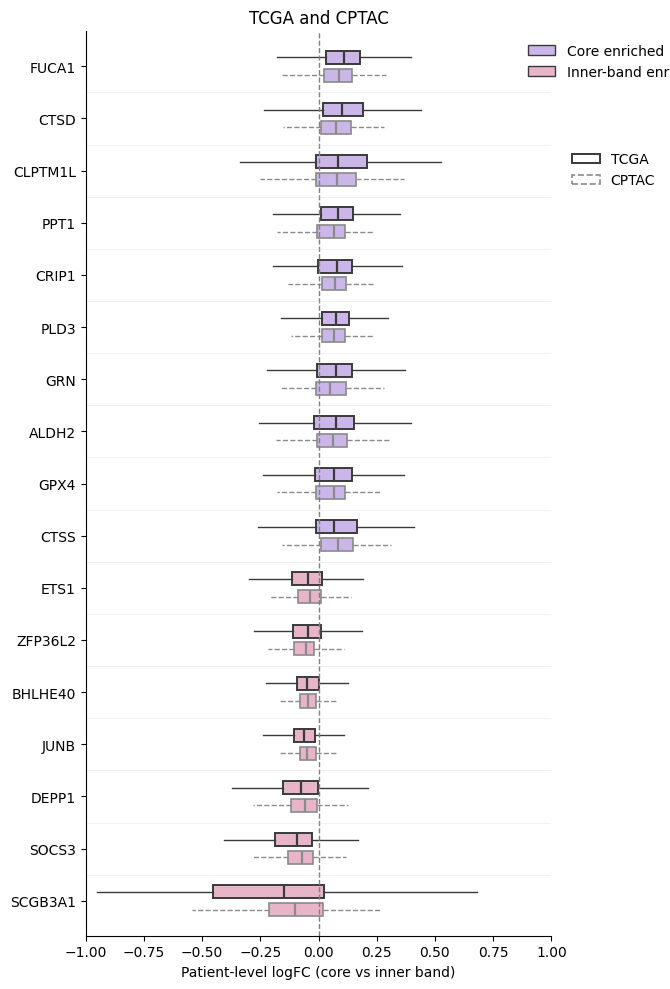

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ----------------------------
# combine TCGA + CPTAC
# ----------------------------
df_tcga_plot = df_tcga[df_tcga["gene"].isin(overlap_genes)].copy()
df_tcga_plot["dataset"] = "TCGA"

df_cptac_plot = df_cptac[df_cptac["gene"].isin(overlap_genes)].copy()
df_cptac_plot["dataset"] = "CPTAC"

plot_df = pd.concat([df_tcga_plot, df_cptac_plot], axis=0).copy()

# ----------------------------
# global clipping
# ----------------------------
plot_df["logFC_inner_vs_core"] = plot_df["logFC_inner_vs_core"].clip(
    lower=-0.95,
    upper=0.95
)

# ----------------------------
# sort by TCGA median
# ----------------------------
tcga_medians = (
    plot_df[plot_df["dataset"] == "TCGA"]
    .groupby("gene")["logFC_inner_vs_core"]
    .median()
    .sort_values(ascending=True)
)

sorted_genes = tcga_medians.index.tolist()

# ----------------------------
# colors
# ----------------------------
direction_colors = {
    "core": "#CBB6E9",
    "inner": "#E8B5C8",
}

medians = (
    plot_df
    .groupby(["gene", "dataset"])["logFC_inner_vs_core"]
    .median()
)

# ----------------------------
# plot
# ----------------------------
fig, ax = plt.subplots(figsize=(7, 10))

y_base = np.arange(len(sorted_genes))
offset = 0.17
box_width = 0.25

for i, gene in enumerate(sorted_genes):

    for dataset in ["TCGA", "CPTAC"]:

        # 🔥 关键修正：TCGA 在上
        if dataset == "TCGA":
            dy = +offset
            edge_color = "#3A3A3A"
            line_style = "-"
            line_width = 1.4
        else:
            dy = -offset
            edge_color = "#8A8A8A"
            line_style = "--"
            line_width = 1.2

        vals = plot_df.loc[
            (plot_df["gene"] == gene) &
            (plot_df["dataset"] == dataset),
            "logFC_inner_vs_core"
        ].dropna().values

        if len(vals) == 0:
            continue

        median_val = medians.loc[(gene, dataset)]
        direction = "core" if median_val > 0 else "inner"
        color = direction_colors[direction]

        ax.boxplot(
            vals,
            positions=[i + dy],
            vert=False,
            widths=box_width,
            patch_artist=True,
            showfliers=False,
            showcaps=False,
            boxprops=dict(
                facecolor=color,
                edgecolor=edge_color,
                linewidth=line_width,
                linestyle=line_style
            ),
            medianprops=dict(color=edge_color, linewidth=1.6),
            whiskerprops=dict(
                color=edge_color,
                linewidth=1,
                linestyle=line_style
            ),
            capprops=dict(linewidth=0)
        )

# ----------------------------
# axis
# ----------------------------
ax.axvline(0, linestyle="--", color="gray", linewidth=1)

ax.set_yticks(y_base)
ax.set_yticklabels(sorted_genes)

ax.set_xlim(-1, 1)
ax.set_xlabel("Patient-level logFC (core vs inner band)")
ax.set_ylabel("")
ax.set_title("TCGA and CPTAC")

# 分隔线
for i in range(len(sorted_genes) - 1):
    ax.axhline(i + 0.5, color="lightgray", lw=0.5, alpha=0.45)

# ----------------------------
# legends
# ----------------------------
direction_legend = [
    Patch(facecolor=direction_colors["core"], edgecolor="#3A3A3A", label="Core enriched"),
    Patch(facecolor=direction_colors["inner"], edgecolor="#3A3A3A", label="Inner-band enriched"),
]

dataset_legend = [
    Patch(
        facecolor="white",
        edgecolor="#3A3A3A",
        linewidth=1.4,
        linestyle="-",
        label="TCGA"
    ),
    Patch(
        facecolor="white",
        edgecolor="#8A8A8A",
        linewidth=1.2,
        linestyle="--",
        label="CPTAC"
    ),
]

leg1 = ax.legend(
    handles=direction_legend,
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(1.36, 1.00)
)

ax.add_artist(leg1)

ax.legend(
    handles=dataset_legend,
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(1.25, 0.88)
)

# 美化
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "./All_fig7/Bio_discovery/Core_inner_DEG.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()